In [1]:
!pip install qiskit qiskit-machine-learning


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
file_path = 'wdbc.data'
column_names = ['id', 'label'] + [f'feature_{i}' for i in range(1, 31)]  # 30 numeric features

# Load into DataFrame
df = pd.read_csv(file_path, header=None, names=column_names)

# Encode labels: 'M' → 1 (malignant), 'B' → 0 (benign)
df['label'] = df['label'].map({'M': 1, 'B': 0})

# Drop ID column
df = df.drop(columns=['id'])

# Extract features and labels
X = df.drop(columns=['label']).values.astype(float)
y = df['label'].values.astype(int)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dimensionality reduction (adjust n_components to your number of qubits, e.g., 4)
n_qubits = 4
pca = PCA(n_components=n_qubits, random_state=42)
X_encoded = pca.fit_transform(X_scaled)

print("Preprocessed data shape:", X_encoded.shape, y.shape)

Preprocessed data shape: (569, 4) (569,)


In [3]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [4]:
!pip install qiskit-aer


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install qiskit qiskit-machine-learning qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.9 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.26.11
    Uninstalling urllib3-1.26.11:
      Successfully uninstalled urllib3-1.26.11
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.4.0
    Uninstalling typing_extensions-4.4.0:
      Successfully uninstalled typing_extensions-4.4.0━━━━━━━━━━━━  1/14 [typing-extensions]
  Attempting uninstall: python-dateutil━━━━━━━━━━━━━━━━━━━━━━━  1/14 [typing-extensions]
    Found existing installation: python-dateutil 2.8.2━━━━━━━━  1/14 [typing-extensions]
    Uninstalling python-dateutil-2.8.2:━━━━━━━━━━━━━━━━━━━━━━━  1/14 [typing-extensions]
      Successfully uninstalled python-dateutil-2.8.2━━━━━━━━━━  1/14 [typing-extensions]
  Attempting uninstall: PyJWT90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/14 [python-dateutil]
   

In [6]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

_HAS_QISKIT = False
try:
    from qiskit.circuit.library import RealAmplitudes
    from qiskit_machine_learning.algorithms import VQC
    from qiskit_machine_learning.optimizers import COBYLA
    _HAS_QISKIT = True
except ImportError:
    print("Qiskit ML modules not available, using classical fallback.")

class QuantumDecisionTree(BaseEstimator, ClassifierMixin):
    def __init__(self, n_qubits=4, backend=None, random_state=42):
        self.n_qubits = n_qubits
        self.random_state = random_state
        self.backend = backend
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=self.n_qubits, random_state=self.random_state)
        self.vqc = None
        self.classical_model = LogisticRegression(random_state=self.random_state)

    def _build_quantum_classifier(self):
        feature_map = RealAmplitudes(num_qubits=self.n_qubits, reps=2)
        optimizer = COBYLA(maxiter=100)

        self.vqc = VQC(
            optimizer=optimizer,
            feature_map=feature_map,
            backend=self.backend  # Use backend directly
        )

    def fit(self, X, y):
        X = self.scaler.fit_transform(X)
        X = self.pca.fit_transform(X)

        if _HAS_QISKIT and self.backend is not None:
            self._build_quantum_classifier()
            self.vqc.fit(X, y)
        else:
            self.classical_model.fit(X, y)

        return self

    def predict(self, X):
        X = self.scaler.transform(X)
        X = self.pca.transform(X)

        if _HAS_QISKIT and self.backend is not None:
            return self.vqc.predict(X)
        else:
            return self.classical_model.predict(X)

    def predict_proba(self, X):
        X = self.scaler.transform(X)
        X = self.pca.transform(X)

        if _HAS_QISKIT and self.backend is not None:
            proba = self.vqc.predict(X)
            return np.vstack([1 - proba, proba]).T
        else:
            return self.classical_model.predict_proba(X)

    def score(self, X, y):
        from sklearn.metrics import accuracy_score
        return accuracy_score(y, self.predict(X))



In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)



In [8]:
clf = QuantumDecisionTree(n_qubits=n_qubits, backend=None, random_state=42)
clf.fit(X_train, y_train)


QuantumDecisionTree()

In [9]:
clf = QuantumDecisionTree(n_qubits=n_qubits, backend=None, random_state=42)
clf.fit(X_train, y_train)

accuracy = clf.score(X_test, y_test)
print(f"Quantum Decision Tree accuracy: {accuracy:.4f}")


Quantum Decision Tree accuracy: 0.9649


In [10]:
from qiskit.circuit.library import RealAmplitudes

n_qubits = 4
feature_map = RealAmplitudes(num_qubits=n_qubits, reps=2)

# Decompose for full visualization
circuit = feature_map.decompose()

# Option 1: Text output (always works)
print(circuit.draw(output='text', fold=120))



     ┌──────────┐                             ┌──────────┐                          ┌──────────┐
q_0: ┤ Ry(θ[0]) ├──────────────────────■──────┤ Ry(θ[4]) ├───────────────────■──────┤ Ry(θ[8]) ├
     ├──────────┤                    ┌─┴─┐    ├──────────┤                 ┌─┴─┐    ├──────────┤
q_1: ┤ Ry(θ[1]) ├──────────■─────────┤ X ├────┤ Ry(θ[5]) ├──────■──────────┤ X ├────┤ Ry(θ[9]) ├
     ├──────────┤        ┌─┴─┐    ┌──┴───┴───┐└──────────┘    ┌─┴─┐    ┌───┴───┴───┐└──────────┘
q_2: ┤ Ry(θ[2]) ├──■─────┤ X ├────┤ Ry(θ[6]) ├─────■──────────┤ X ├────┤ Ry(θ[10]) ├────────────
     ├──────────┤┌─┴─┐┌──┴───┴───┐└──────────┘   ┌─┴─┐    ┌───┴───┴───┐└───────────┘            
q_3: ┤ Ry(θ[3]) ├┤ X ├┤ Ry(θ[7]) ├───────────────┤ X ├────┤ Ry(θ[11]) ├─────────────────────────
     └──────────┘└───┘└──────────┘               └───┘    └───────────┘                         


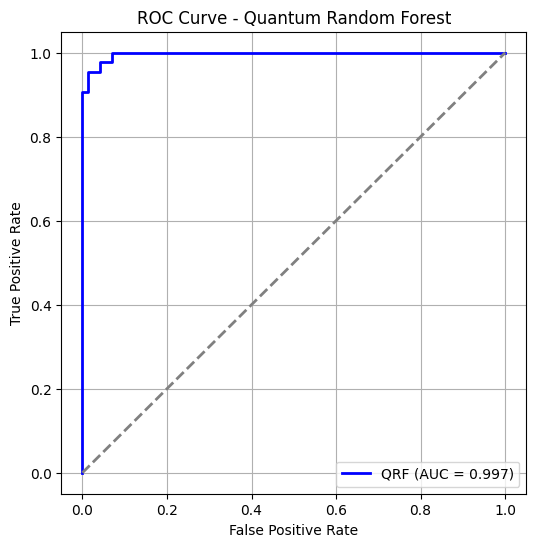

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Step 3: ROC Curve ---
y_proba = clf.predict_proba(X_test)[:, 1]   # probability for positive class
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# --- Step 4: Plot ---
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"QRF (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Quantum Random Forest")
plt.legend(loc="lower right")
plt.grid()
plt.show()